In [1]:
import sunpy
import sunpy.map
import sunpy.coordinates
from sunpy.coordinates import (HeliographicStonyhurst,
                               PlanarScreen)
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import astropy.units as u
import astropy.constants as const
from astropy.visualization import (ImageNormalize,
                                   AsinhStretch,
                                   LinearStretch)
from astropy.coordinates import SkyCoord
import sunkit_image.enhance as enhance
import numpy as np 

In [2]:
aia_map_1018 = sunpy.map.Map("../../src/KB2025/aia.lev1_euv_12s.2022-10-18T190515Z.171.image.fits")
aia_map_1024 = sunpy.map.Map("../../src/KB2025/aia.lev1_euv_12s.2022-10-24T190515Z.171.image.fits")
fsi_map_1018 = sunpy.map.Map("../../src/KB2025/solo_L2_eui-fsi174-image_20221018T190045260_V01.fits")
fsi_map_1024 = sunpy.map.Map("../../src/KB2025/solo_L2_eui-fsi174-image_20221024T190050195_V01.fits")

fsi_map_1018.meta["rsun_ref"] = aia_map_1018.meta["rsun_ref"]
fsi_map_1024.meta["rsun_ref"] = aia_map_1024.meta["rsun_ref"]

In [3]:
aia_map_1018 = enhance.wow(aia_map_1018, bilateral=1, denoise_coefficients=[5, 3, 1], gamma=4, h=0.999)
aia_map_1024 = enhance.wow(aia_map_1024, bilateral=1, denoise_coefficients=[5, 3, 1], gamma=4, h=0.999)

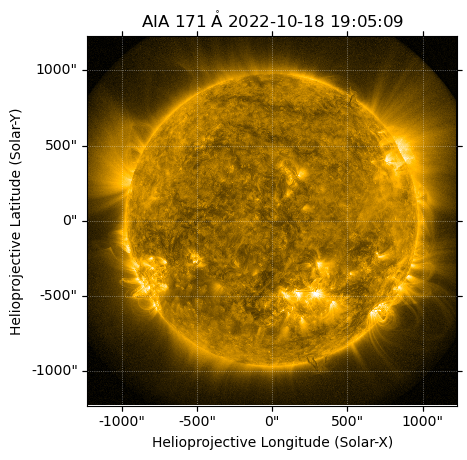

In [4]:
aia_map_1018.plot(norm=ImageNormalize(
                       vmin=np.nanpercentile(aia_map_1018.data, 0.5),
                       vmax=np.nanpercentile(aia_map_1018.data, 99.99),
                       stretch=AsinhStretch(0.5)))

In [5]:
aia_fov = aia_map_1018.top_right_coord.Tx - aia_map_1018.bottom_left_coord.Tx
fsi_crop_nx_1018 = np.round(aia_fov/fsi_map_1018.scale.axis1*\
                            aia_map_1018.observer_coordinate.radius/\
                            fsi_map_1018.observer_coordinate.radius).astype(int).to_value(u.pix)
fsi_crop_nx_1024 = np.round(aia_fov/fsi_map_1024.scale.axis1*\
                            aia_map_1024.observer_coordinate.radius/\
                            fsi_map_1024.observer_coordinate.radius).astype(int).to_value(u.pix)

print(fsi_crop_nx_1018, fsi_crop_nx_1024)

1707 1401


In [6]:
fsi_map_1018_disk_center = fsi_map_1018.world_to_pixel(SkyCoord(0*u.deg, 0*u.deg, frame=fsi_map_1018.coordinate_frame))
fsi_map_1018_disk_center_x = np.round(fsi_map_1018_disk_center[0]).astype(int).to_value(u.pix)
fsi_map_1018_disk_center_y = np.round(fsi_map_1018_disk_center[1]).astype(int).to_value(u.pix)
fsi_map_1018_crop = fsi_map_1018.submap(bottom_left=[fsi_map_1018_disk_center_x-(fsi_crop_nx_1018-1)/2,
                                                     fsi_map_1018_disk_center_y-(fsi_crop_nx_1018-1)/2]*u.pix,
                                        top_right=[fsi_map_1018_disk_center_x+(fsi_crop_nx_1018-1)/2,
                                                    fsi_map_1018_disk_center_y+(fsi_crop_nx_1018-1)/2]*u.pix)
fsi_map_1018_crop = enhance.wow(fsi_map_1018_crop, bilateral=1, denoise_coefficients=[5, 3, 1], gamma=4, h=0.999)

In [7]:
fsi_map_1018_rotate = fsi_map_1018.rotate()
fsi_map_1018_disk_center_rotate = fsi_map_1018_rotate.world_to_pixel(SkyCoord(0*u.deg, 0*u.deg, frame=fsi_map_1018_rotate.coordinate_frame))
fsi_map_1018_disk_center_x_rotate = np.round(fsi_map_1018_disk_center_rotate[0]).astype(int).to_value(u.pix)
fsi_map_1018_disk_center_y_rotate = np.round(fsi_map_1018_disk_center_rotate[1]).astype(int).to_value(u.pix)
fsi_map_1018_crop_rotate = fsi_map_1018_rotate.submap(bottom_left=[fsi_map_1018_disk_center_x_rotate-(fsi_crop_nx_1018-1)/2,
                                                                     fsi_map_1018_disk_center_y_rotate-(fsi_crop_nx_1018-1)/2]*u.pix,
                                                        top_right=[fsi_map_1018_disk_center_x_rotate+(fsi_crop_nx_1018-1)/2,
                                                                   fsi_map_1018_disk_center_y_rotate+(fsi_crop_nx_1018-1)/2]*u.pix)
fsi_map_1018_crop_rotate = enhance.wow(fsi_map_1018_crop_rotate, bilateral=1, denoise_coefficients=[5, 3, 1], gamma=4, h=0.999)

In [8]:
fsi_map_1024_disk_center = fsi_map_1024.world_to_pixel(SkyCoord(0*u.deg, 0*u.deg, frame=fsi_map_1024.coordinate_frame))
fsi_map_1024_disk_center_x = np.round(fsi_map_1024_disk_center[0]).astype(int).to_value(u.pix)
fsi_map_1024_disk_center_y = np.round(fsi_map_1024_disk_center[1]).astype(int).to_value(u.pix)
fsi_map_1024_crop = fsi_map_1024.submap(bottom_left=[fsi_map_1024_disk_center_x-(fsi_crop_nx_1024-1)/2,
                                                     fsi_map_1024_disk_center_y-(fsi_crop_nx_1024-1)/2]*u.pix,
                                        top_right=[fsi_map_1024_disk_center_x+(fsi_crop_nx_1024-1)/2,
                                                    fsi_map_1024_disk_center_y+(fsi_crop_nx_1024-1)/2]*u.pix)
fsi_map_1024_crop = enhance.wow(fsi_map_1024_crop, bilateral=1, denoise_coefficients=[5, 3, 1], gamma=4, h=0.999)

In [9]:
fsi_map_1024_rotate = fsi_map_1024.rotate()
fsi_map_1024_disk_center_rotate = fsi_map_1024_rotate.world_to_pixel(SkyCoord(0*u.deg, 0*u.deg, frame=fsi_map_1024_rotate.coordinate_frame))
fsi_map_1024_disk_center_x_rotate = np.round(fsi_map_1024_disk_center_rotate[0]).astype(int).to_value(u.pix)
fsi_map_1024_disk_center_y_rotate = np.round(fsi_map_1024_disk_center_rotate[1]).astype(int).to_value(u.pix)
fsi_map_1024_crop_rotate = fsi_map_1024_rotate.submap(bottom_left=[fsi_map_1024_disk_center_x_rotate-(fsi_crop_nx_1024-1)/2,
                                                                   fsi_map_1024_disk_center_y_rotate-(fsi_crop_nx_1024-1)/2]*u.pix,
                                                      top_right=[fsi_map_1024_disk_center_x_rotate+(fsi_crop_nx_1024-1)/2,
                                                                 fsi_map_1024_disk_center_y_rotate+(fsi_crop_nx_1024-1)/2]*u.pix)
fsi_map_1024_crop_rotate = enhance.wow(fsi_map_1024_crop_rotate, bilateral=1, denoise_coefficients=[5, 3, 1], gamma=4, h=0.999)

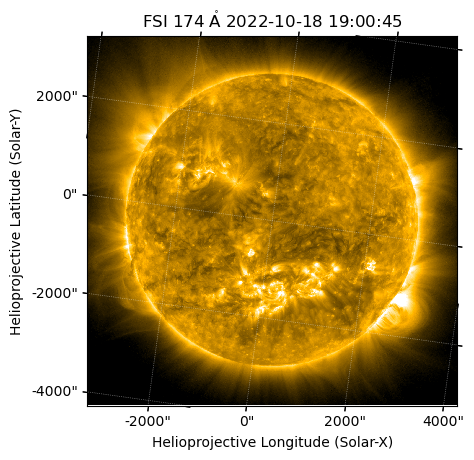

In [10]:
fsi_map_1018_crop.plot(norm=ImageNormalize(
                       vmin=np.nanpercentile(aia_map_1018.data, 0.5),
                       vmax=np.nanpercentile(aia_map_1018.data, 99.99),
                       stretch=AsinhStretch(0.5)))

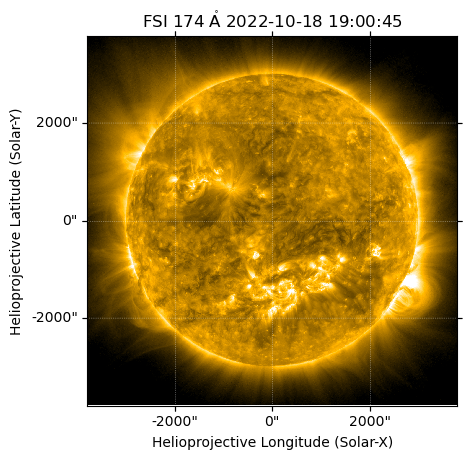

In [11]:
fsi_map_1018_crop_rotate.plot(norm=ImageNormalize(
                          vmin=np.nanpercentile(aia_map_1018.data, 0.5),
                          vmax=np.nanpercentile(aia_map_1018.data, 99.99),
                          stretch=AsinhStretch(0.5)))

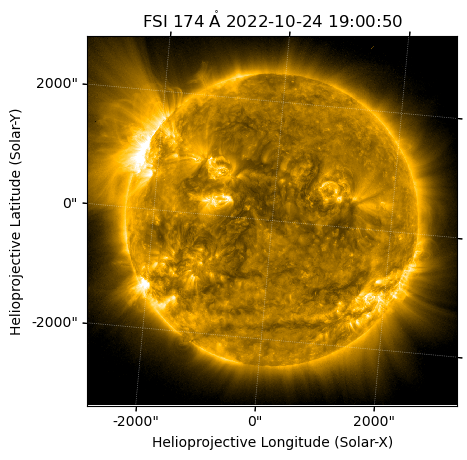

In [12]:
fsi_map_1024_crop.plot(norm=ImageNormalize(
                       vmin=np.nanpercentile(aia_map_1024.data, 0.5),
                       vmax=np.nanpercentile(aia_map_1024.data, 99.99),
                       stretch=AsinhStretch(0.5)))

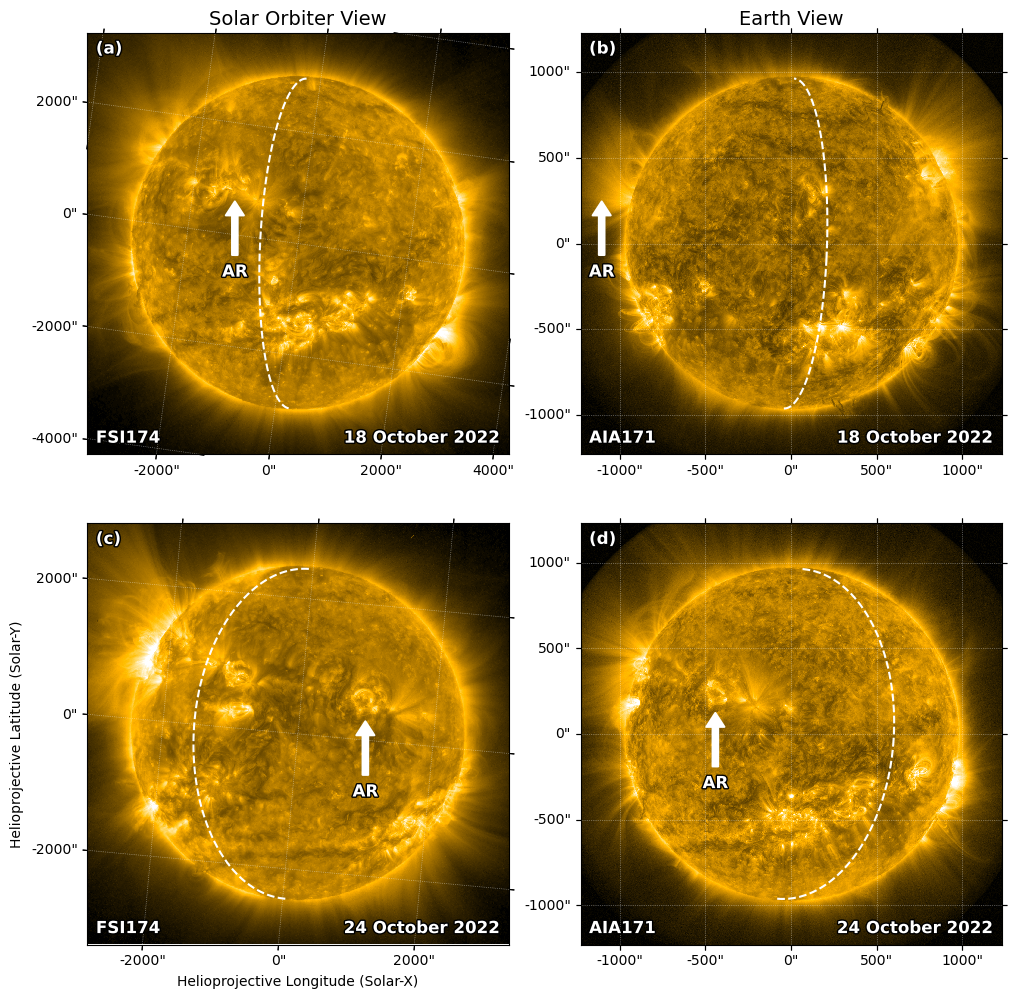

In [13]:
fig = plt.figure(figsize=(10, 10), layout="constrained")

ax1 = fig.add_subplot(2, 2, 1, projection=fsi_map_1018_crop)
fsi_map_1018_crop.plot(axes=ax1, title=None, norm=ImageNormalize(
                       vmin=np.nanpercentile(fsi_map_1018_crop.data, 0.5),
                       vmax=np.nanpercentile(fsi_map_1018_crop.data, 99.99),
                       stretch=AsinhStretch(0.5)))

ax1.text(0.02, 0.02, "FSI174", color="white", fontsize=12,
        transform=ax1.transAxes, ha="left", va="bottom",
        weight="bold",
        path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                      path_effects.Normal()])

ax1.text(0.98, 0.02, "18 October 2022", color="white", fontsize=12,
         transform=ax1.transAxes, ha="right", va="bottom",
         weight="bold",
         path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                       path_effects.Normal()])

ax1.text(0.02, 0.98, "(a)", color="white", fontsize=12,
         transform=ax1.transAxes, ha="left", va="top",
         weight="bold",
         path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                      path_effects.Normal()])

ax1.set_title("Solar Orbiter View", fontsize=14,)

ax1.annotate("AR", (0.35,0.6), (0.35, 0.45), 
             fontsize=12,color="white",weight="bold",
             path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                            path_effects.Normal()],
             va="top", ha="center",
             bbox=dict(pad=7, facecolor="none", edgecolor="none"),
             arrowprops=dict(width=4, headwidth=13,
                            headlength=10,
                        #  facecolor='#DA291C',
                            facecolor='white',
                            linewidth=1.5, edgecolor='#FFFFFF'),
             xycoords=ax1.transAxes)

ax1_visible_limb, ax1_hidden_limb = aia_map_1018.draw_limb(axes=ax1, color='white', lw=1.5, alpha=1, ls="--")
ax1_hidden_limb.set_visible(False)

ax2 = fig.add_subplot(2, 2, 2, projection=aia_map_1018)
aia_map_1018.plot(axes=ax2, title=None, norm=ImageNormalize(
                       vmin=np.nanpercentile(aia_map_1018.data, 0.5),
                       vmax=np.nanpercentile(aia_map_1018.data, 99.99),
                       stretch=AsinhStretch(0.5)))

ax2.text(0.02, 0.02, "AIA171", color="white", fontsize=12,
        transform=ax2.transAxes, ha="left", va="bottom",
        weight="bold",
        path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                      path_effects.Normal()])

ax2.text(0.98, 0.02, "18 October 2022", color="white", fontsize=12,
        transform=ax2.transAxes, ha="right", va="bottom",
        weight="bold",
        path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                        path_effects.Normal()])

ax2.text(0.02, 0.98, "(b)", color="white", fontsize=12,
            transform=ax2.transAxes, ha="left", va="top",
            weight="bold",
            path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                        path_effects.Normal()])

ax2.set_title("Earth View", fontsize=14,)

ax2.annotate("AR", (0.05,0.6), (0.05, 0.45), 
             fontsize=12,color="white",weight="bold",
             path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                            path_effects.Normal()],
             va="top", ha="center",
             bbox=dict(pad=7, facecolor="none", edgecolor="none"),
             arrowprops=dict(width=4, headwidth=13,
                            headlength=10,
                        #  facecolor='#DA291C',
                            facecolor='white',
                            linewidth=1.5, edgecolor='#FFFFFF'),
             xycoords=ax2.transAxes)

ax2_visible_limb, ax2_hidden_limb = fsi_map_1018.draw_limb(axes=ax2, color='white', lw=1.5, alpha=1, ls="--")
ax2_hidden_limb.set_visible(False)

ax3 = fig.add_subplot(2, 2, 3, projection=fsi_map_1024_crop)
fsi_map_1024_crop.plot(axes=ax3, title=None, norm=ImageNormalize(
                       vmin=np.nanpercentile(fsi_map_1024_crop.data, 0.5),
                       vmax=np.nanpercentile(fsi_map_1024_crop.data, 99.99),
                       stretch=AsinhStretch(0.5)))

ax3.text(0.02, 0.02, "FSI174", color="white", fontsize=12,
        transform=ax3.transAxes, ha="left", va="bottom",
        weight="bold",
        path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                      path_effects.Normal()])

ax3.text(0.98, 0.02, "24 October 2022", color="white", fontsize=12,
        transform=ax3.transAxes, ha="right", va="bottom",
        weight="bold",
        path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                      path_effects.Normal()])

ax3.text(0.02, 0.98, "(c)", color="white", fontsize=12,
        transform=ax3.transAxes, ha="left", va="top",
        weight="bold",
        path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                      path_effects.Normal()])

ax3.annotate("AR", (0.66,0.53), (0.66, 0.38), 
             fontsize=12,color="white",weight="bold",
             path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                            path_effects.Normal()],
             va="top", ha="center",
             bbox=dict(pad=7, facecolor="none", edgecolor="none"),
             arrowprops=dict(width=4, headwidth=13,
                            headlength=10,
                        #  facecolor='#DA291C',
                            facecolor='white',
                            linewidth=1.5, edgecolor='#FFFFFF'),
             xycoords=ax3.transAxes)

ax3_visible_limb, ax3_hidden_limb = aia_map_1024.draw_limb(axes=ax3, color='white', lw=1.5, alpha=1, ls="--")
ax3_hidden_limb.set_visible(False)


ax4 = fig.add_subplot(2, 2, 4, projection=aia_map_1024)
aia_map_1024.plot(axes=ax4, title=None, norm=ImageNormalize(
                       vmin=np.nanpercentile(aia_map_1018.data, 0.5),
                       vmax=np.nanpercentile(aia_map_1018.data, 99.99),
                       stretch=AsinhStretch(0.5)))

ax4.text(0.02, 0.02, "AIA171", color="white", fontsize=12,
        transform=ax4.transAxes, ha="left", va="bottom",
        weight="bold",
        path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                      path_effects.Normal()])

ax4.text(0.98, 0.02, "24 October 2022", color="white", fontsize=12,
        transform=ax4.transAxes, ha="right", va="bottom",
        weight="bold",
        path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                      path_effects.Normal()])

ax4.text(0.02, 0.98, "(d)", color="white", fontsize=12,
        transform=ax4.transAxes, ha="left", va="top",
        weight="bold",
        path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                      path_effects.Normal()])

ax4.annotate("AR", (0.32,0.55), (0.32, 0.4), 
             fontsize=12,color="white",weight="bold",
             path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                            path_effects.Normal()],
             va="top", ha="center",
             bbox=dict(pad=7, facecolor="none", edgecolor="none"),
             arrowprops=dict(width=4, headwidth=13,
                            headlength=10,
                        #  facecolor='#DA291C',
                            facecolor='white',
                            linewidth=1.5, edgecolor='#FFFFFF'),
             xycoords=ax4.transAxes)

ax4_visible_limb, ax4_hidden_limb = fsi_map_1024.draw_limb(axes=ax4, color='white', lw=1.5, alpha=1, ls="--")
ax4_hidden_limb.set_visible(False)

for ax in (ax1,ax2,ax4):
    ax.coords[0].axislabels.set_visible(False)
    ax.coords[1].axislabels.set_visible(False)

fig.savefig("../../figs/KB2025/fig2_primary_norot_nohgs.pdf", dpi=300, bbox_inches="tight")

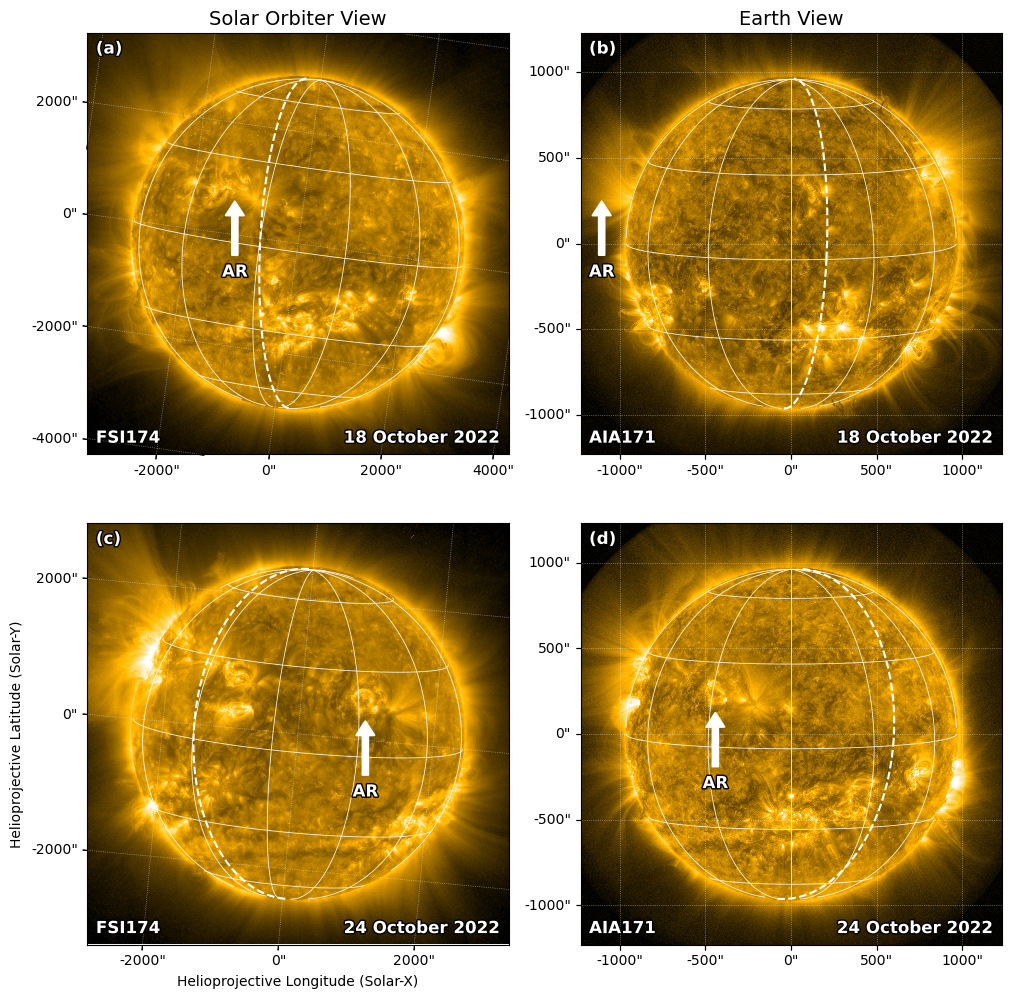

In [14]:
fig = plt.figure(figsize=(10, 10), layout="constrained")

ax1 = fig.add_subplot(2, 2, 1, projection=fsi_map_1018_crop)
fsi_map_1018_crop.plot(axes=ax1, title=None, norm=ImageNormalize(
                       vmin=np.nanpercentile(fsi_map_1018_crop.data, 0.5),
                       vmax=np.nanpercentile(fsi_map_1018_crop.data, 99.99),
                       stretch=AsinhStretch(0.5)))

ax1.text(0.02, 0.02, "FSI174", color="white", fontsize=12,
        transform=ax1.transAxes, ha="left", va="bottom",
        weight="bold",
        path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                      path_effects.Normal()])

ax1.text(0.98, 0.02, "18 October 2022", color="white", fontsize=12,
         transform=ax1.transAxes, ha="right", va="bottom",
         weight="bold",
         path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                       path_effects.Normal()])

ax1.text(0.02, 0.98, "(a)", color="white", fontsize=12,
         transform=ax1.transAxes, ha="left", va="top",
         weight="bold",
         path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                      path_effects.Normal()])

ax1.set_title("Solar Orbiter View", fontsize=14,)

ax1.annotate("AR", (0.35,0.6), (0.35, 0.45), 
             fontsize=12,color="white",weight="bold",
             path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                            path_effects.Normal()],
             va="top", ha="center",
             bbox=dict(pad=7, facecolor="none", edgecolor="none"),
             arrowprops=dict(width=4, headwidth=13,
                            headlength=10,
                        #  facecolor='#DA291C',
                            facecolor='white',
                            linewidth=1.5, edgecolor='#FFFFFF'),
             xycoords=ax1.transAxes)

ax1_visible_limb, ax1_hidden_limb = aia_map_1018.draw_limb(axes=ax1, color='white', lw=1.5, alpha=1, ls="--")
ax1_hidden_limb.set_visible(False)

fsi_map_1018.draw_grid(axes=ax1, grid_spacing=30*u.deg, lw=0.6, alpha=0.9,
                       color="white",annotate=False)

ax2 = fig.add_subplot(2, 2, 2, projection=aia_map_1018)
aia_map_1018.plot(axes=ax2, title=None, norm=ImageNormalize(
                       vmin=np.nanpercentile(aia_map_1018.data, 0.5),
                       vmax=np.nanpercentile(aia_map_1018.data, 99.99),
                       stretch=AsinhStretch(0.5)))

ax2.text(0.02, 0.02, "AIA171", color="white", fontsize=12,
        transform=ax2.transAxes, ha="left", va="bottom",
        weight="bold",
        path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                      path_effects.Normal()])

ax2.text(0.98, 0.02, "18 October 2022", color="white", fontsize=12,
        transform=ax2.transAxes, ha="right", va="bottom",
        weight="bold",
        path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                        path_effects.Normal()])

ax2.text(0.02, 0.98, "(b)", color="white", fontsize=12,
            transform=ax2.transAxes, ha="left", va="top",
            weight="bold",
            path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                        path_effects.Normal()])

ax2.set_title("Earth View", fontsize=14,)

ax2.annotate("AR", (0.05,0.6), (0.05, 0.45), 
             fontsize=12,color="white",weight="bold",
             path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                            path_effects.Normal()],
             va="top", ha="center",
             bbox=dict(pad=7, facecolor="none", edgecolor="none"),
             arrowprops=dict(width=4, headwidth=13,
                            headlength=10,
                        #  facecolor='#DA291C',
                            facecolor='white',
                            linewidth=1.5, edgecolor='#FFFFFF'),
             xycoords=ax2.transAxes)

ax2_visible_limb, ax2_hidden_limb = fsi_map_1018.draw_limb(axes=ax2, color='white', lw=1.5, alpha=1, ls="--")
ax2_hidden_limb.set_visible(False)

aia_map_1018.draw_grid(axes=ax2, grid_spacing=30*u.deg, lw=0.6, alpha=0.9,
                       color="white",annotate=False)

ax3 = fig.add_subplot(2, 2, 3, projection=fsi_map_1024_crop)
fsi_map_1024_crop.plot(axes=ax3, title=None, norm=ImageNormalize(
                       vmin=np.nanpercentile(fsi_map_1024_crop.data, 0.5),
                       vmax=np.nanpercentile(fsi_map_1024_crop.data, 99.99),
                       stretch=AsinhStretch(0.5)))

ax3.text(0.02, 0.02, "FSI174", color="white", fontsize=12,
        transform=ax3.transAxes, ha="left", va="bottom",
        weight="bold",
        path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                      path_effects.Normal()])

ax3.text(0.98, 0.02, "24 October 2022", color="white", fontsize=12,
        transform=ax3.transAxes, ha="right", va="bottom",
        weight="bold",
        path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                      path_effects.Normal()])

ax3.text(0.02, 0.98, "(c)", color="white", fontsize=12,
        transform=ax3.transAxes, ha="left", va="top",
        weight="bold",
        path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                      path_effects.Normal()])

ax3.annotate("AR", (0.66,0.53), (0.66, 0.38), 
             fontsize=12,color="white",weight="bold",
             path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                            path_effects.Normal()],
             va="top", ha="center",
             bbox=dict(pad=7, facecolor="none", edgecolor="none"),
             arrowprops=dict(width=4, headwidth=13,
                            headlength=10,
                        #  facecolor='#DA291C',
                            facecolor='white',
                            linewidth=1.5, edgecolor='#FFFFFF'),
             xycoords=ax3.transAxes)

ax3_visible_limb, ax3_hidden_limb = aia_map_1024.draw_limb(axes=ax3, color='white', lw=1.5, alpha=1, ls="--")
ax3_hidden_limb.set_visible(False)

fsi_map_1024.draw_grid(axes=ax3, grid_spacing=30*u.deg, lw=0.6, alpha=0.9,
                       color="white",annotate=False)

ax4 = fig.add_subplot(2, 2, 4, projection=aia_map_1024)
aia_map_1024.plot(axes=ax4, title=None, norm=ImageNormalize(
                       vmin=np.nanpercentile(aia_map_1018.data, 0.5),
                       vmax=np.nanpercentile(aia_map_1018.data, 99.99),
                       stretch=AsinhStretch(0.5)))

ax4.text(0.02, 0.02, "AIA171", color="white", fontsize=12,
        transform=ax4.transAxes, ha="left", va="bottom",
        weight="bold",
        path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                      path_effects.Normal()])

ax4.text(0.98, 0.02, "24 October 2022", color="white", fontsize=12,
        transform=ax4.transAxes, ha="right", va="bottom",
        weight="bold",
        path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                      path_effects.Normal()])

ax4.text(0.02, 0.98, "(d)", color="white", fontsize=12,
        transform=ax4.transAxes, ha="left", va="top",
        weight="bold",
        path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                      path_effects.Normal()])

ax4.annotate("AR", (0.32,0.55), (0.32, 0.4), 
             fontsize=12,color="white",weight="bold",
             path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                            path_effects.Normal()],
             va="top", ha="center",
             bbox=dict(pad=7, facecolor="none", edgecolor="none"),
             arrowprops=dict(width=4, headwidth=13,
                            headlength=10,
                        #  facecolor='#DA291C',
                            facecolor='white',
                            linewidth=1.5, edgecolor='#FFFFFF'),
             xycoords=ax4.transAxes)

aia_map_1024.draw_grid(axes=ax4, grid_spacing=30*u.deg, lw=0.6, alpha=0.9,
                       color="white", annotate=False)

ax4_visible_limb, ax4_hidden_limb = fsi_map_1024.draw_limb(axes=ax4, color='white', lw=1.5, alpha=1, ls="--")
ax4_hidden_limb.set_visible(False)


for ax in (ax1,ax2,ax4):
    ax.coords[0].axislabels.set_visible(False)
    ax.coords[1].axislabels.set_visible(False)

fig.savefig("../../figs/KB2025/fig2_backup_norot_hgs.pdf", dpi=300, bbox_inches="tight")


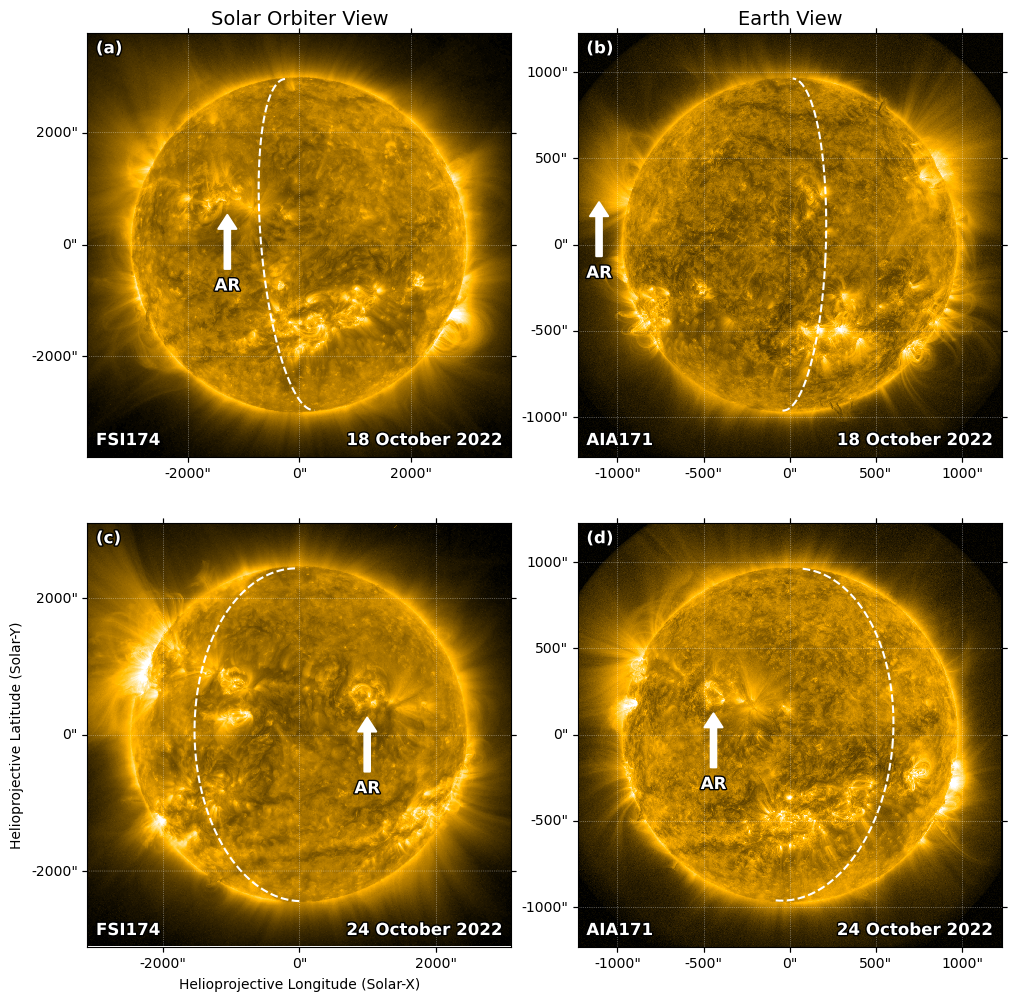

In [15]:
fig = plt.figure(figsize=(10, 10), layout="constrained")

ax1 = fig.add_subplot(2, 2, 1, projection=fsi_map_1018_crop_rotate)
fsi_map_1018_crop_rotate.plot(axes=ax1, title=None, norm=ImageNormalize(
                       vmin=np.nanpercentile(fsi_map_1018_crop_rotate.data, 0.5),
                       vmax=np.nanpercentile(fsi_map_1018_crop_rotate.data, 99.99),
                       stretch=AsinhStretch(0.5)))

ax1.text(0.02, 0.02, "FSI174", color="white", fontsize=12,
        transform=ax1.transAxes, ha="left", va="bottom",
        weight="bold",
        path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                      path_effects.Normal()])

ax1.text(0.98, 0.02, "18 October 2022", color="white", fontsize=12,
         transform=ax1.transAxes, ha="right", va="bottom",
         weight="bold",
         path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                       path_effects.Normal()])

ax1.text(0.02, 0.98, "(a)", color="white", fontsize=12,
         transform=ax1.transAxes, ha="left", va="top",
         weight="bold",
         path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                      path_effects.Normal()])

ax1.set_title("Solar Orbiter View", fontsize=14,)

ax1.annotate("AR", (0.33,0.57), (0.33, 0.42), 
             fontsize=12,color="white",weight="bold",
             path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                            path_effects.Normal()],
             va="top", ha="center",
             bbox=dict(pad=7, facecolor="none", edgecolor="none"),
             arrowprops=dict(width=4, headwidth=13,
                            headlength=10,
                        #  facecolor='#DA291C',
                            facecolor='white',
                            linewidth=1.5, edgecolor='#FFFFFF'),
             xycoords=ax1.transAxes)

ax1_visible_limb, ax1_hidden_limb = aia_map_1018.draw_limb(axes=ax1, color='white', lw=1.5, alpha=1, ls="--")
ax1_hidden_limb.set_visible(False)

ax2 = fig.add_subplot(2, 2, 2, projection=aia_map_1018)
aia_map_1018.plot(axes=ax2, title=None, norm=ImageNormalize(
                       vmin=np.nanpercentile(aia_map_1018.data, 0.5),
                       vmax=np.nanpercentile(aia_map_1018.data, 99.99),
                       stretch=AsinhStretch(0.5)))

ax2.text(0.02, 0.02, "AIA171", color="white", fontsize=12,
        transform=ax2.transAxes, ha="left", va="bottom",
        weight="bold",
        path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                      path_effects.Normal()])

ax2.text(0.98, 0.02, "18 October 2022", color="white", fontsize=12,
        transform=ax2.transAxes, ha="right", va="bottom",
        weight="bold",
        path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                        path_effects.Normal()])

ax2.text(0.02, 0.98, "(b)", color="white", fontsize=12,
            transform=ax2.transAxes, ha="left", va="top",
            weight="bold",
            path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                        path_effects.Normal()])

ax2.set_title("Earth View", fontsize=14,)

ax2.annotate("AR", (0.05,0.6), (0.05, 0.45), 
             fontsize=12,color="white",weight="bold",
             path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                            path_effects.Normal()],
             va="top", ha="center",
             bbox=dict(pad=7, facecolor="none", edgecolor="none"),
             arrowprops=dict(width=4, headwidth=13,
                            headlength=10,
                        #  facecolor='#DA291C',
                            facecolor='white',
                            linewidth=1.5, edgecolor='#FFFFFF'),
             xycoords=ax2.transAxes)

ax2_visible_limb, ax2_hidden_limb = fsi_map_1018.draw_limb(axes=ax2, color='white', lw=1.5, alpha=1, ls="--")
ax2_hidden_limb.set_visible(False)

ax3 = fig.add_subplot(2, 2, 3, projection=fsi_map_1024_crop_rotate)
fsi_map_1024_crop_rotate.plot(axes=ax3, title=None, norm=ImageNormalize(
                       vmin=np.nanpercentile(fsi_map_1024_crop_rotate.data, 0.5),
                       vmax=np.nanpercentile(fsi_map_1024_crop_rotate.data, 99.99),
                       stretch=AsinhStretch(0.5)))

ax3.text(0.02, 0.02, "FSI174", color="white", fontsize=12,
        transform=ax3.transAxes, ha="left", va="bottom",
        weight="bold",
        path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                      path_effects.Normal()])

ax3.text(0.98, 0.02, "24 October 2022", color="white", fontsize=12,
        transform=ax3.transAxes, ha="right", va="bottom",
        weight="bold",
        path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                      path_effects.Normal()])

ax3.text(0.02, 0.98, "(c)", color="white", fontsize=12,
        transform=ax3.transAxes, ha="left", va="top",
        weight="bold",
        path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                      path_effects.Normal()])

ax3.annotate("AR", (0.66,0.54), (0.66, 0.39), 
             fontsize=12,color="white",weight="bold",
             path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                            path_effects.Normal()],
             va="top", ha="center",
             bbox=dict(pad=7, facecolor="none", edgecolor="none"),
             arrowprops=dict(width=4, headwidth=13,
                            headlength=10,
                        #  facecolor='#DA291C',
                            facecolor='white',
                            linewidth=1.5, edgecolor='#FFFFFF'),
             xycoords=ax3.transAxes)

ax3_visible_limb, ax3_hidden_limb = aia_map_1024.draw_limb(axes=ax3, color='white', lw=1.5, alpha=1, ls="--")
ax3_hidden_limb.set_visible(False)


ax4 = fig.add_subplot(2, 2, 4, projection=aia_map_1024)
aia_map_1024.plot(axes=ax4, title=None, norm=ImageNormalize(
                       vmin=np.nanpercentile(aia_map_1018.data, 0.5),
                       vmax=np.nanpercentile(aia_map_1018.data, 99.99),
                       stretch=AsinhStretch(0.5)))

ax4.text(0.02, 0.02, "AIA171", color="white", fontsize=12,
        transform=ax4.transAxes, ha="left", va="bottom",
        weight="bold",
        path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                      path_effects.Normal()])

ax4.text(0.98, 0.02, "24 October 2022", color="white", fontsize=12,
        transform=ax4.transAxes, ha="right", va="bottom",
        weight="bold",
        path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                      path_effects.Normal()])

ax4.text(0.02, 0.98, "(d)", color="white", fontsize=12,
        transform=ax4.transAxes, ha="left", va="top",
        weight="bold",
        path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                      path_effects.Normal()])

ax4.annotate("AR", (0.32,0.55), (0.32, 0.4), 
             fontsize=12,color="white",weight="bold",
             path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                            path_effects.Normal()],
             va="top", ha="center",
             bbox=dict(pad=7, facecolor="none", edgecolor="none"),
             arrowprops=dict(width=4, headwidth=13,
                            headlength=10,
                        #  facecolor='#DA291C',
                            facecolor='white',
                            linewidth=1.5, edgecolor='#FFFFFF'),
             xycoords=ax4.transAxes)

ax4_visible_limb, ax4_hidden_limb = fsi_map_1024.draw_limb(axes=ax4, color='white', lw=1.5, alpha=1, ls="--")
ax4_hidden_limb.set_visible(False)

for ax in (ax1,ax2,ax4):
    ax.coords[0].axislabels.set_visible(False)
    ax.coords[1].axislabels.set_visible(False)

fig.savefig("../../figs/KB2025/fig2_backup_rot_nohgs.pdf", dpi=300, bbox_inches="tight")

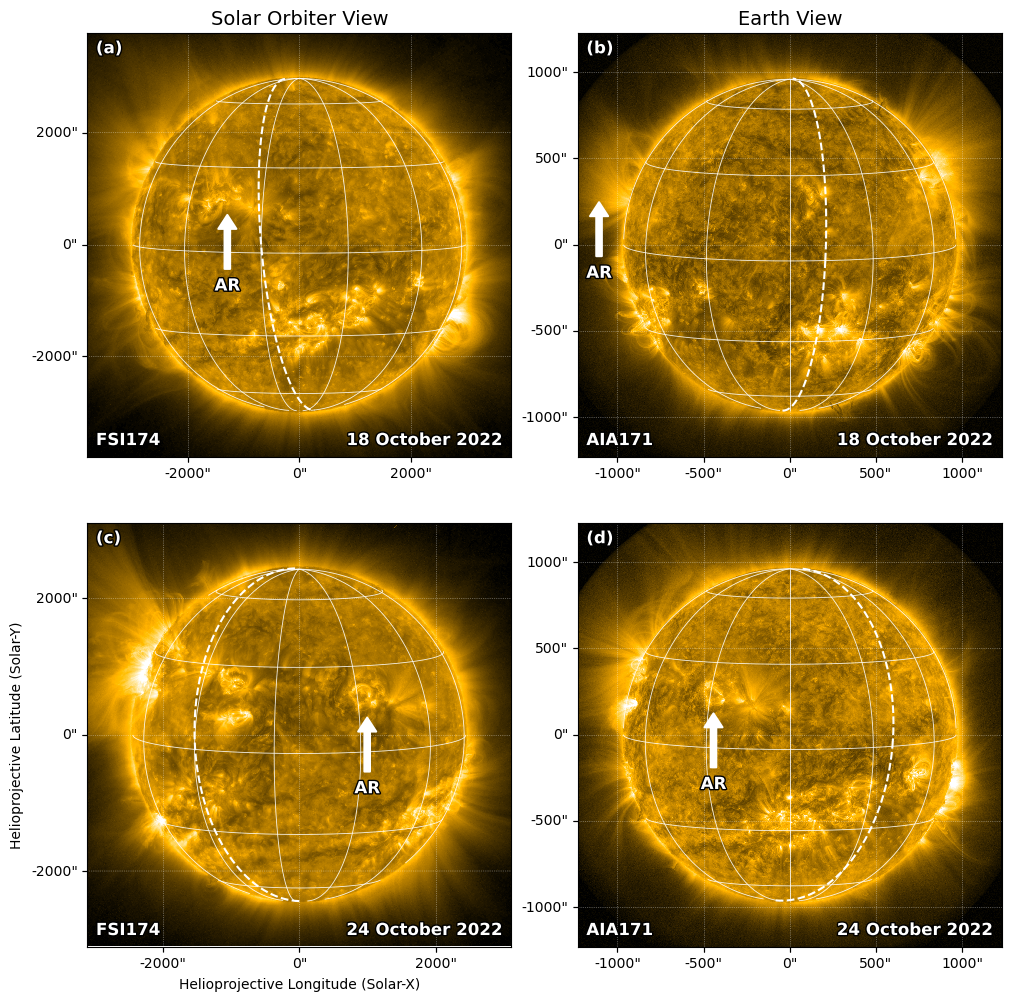

In [16]:
fig = plt.figure(figsize=(10, 10), layout="constrained")

ax1 = fig.add_subplot(2, 2, 1, projection=fsi_map_1018_crop_rotate)
fsi_map_1018_crop_rotate.plot(axes=ax1, title=None, norm=ImageNormalize(
                       vmin=np.nanpercentile(fsi_map_1018_crop_rotate.data, 0.5),
                       vmax=np.nanpercentile(fsi_map_1018_crop_rotate.data, 99.99),
                       stretch=AsinhStretch(0.5)))

ax1.text(0.02, 0.02, "FSI174", color="white", fontsize=12,
        transform=ax1.transAxes, ha="left", va="bottom",
        weight="bold",
        path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                      path_effects.Normal()])

ax1.text(0.98, 0.02, "18 October 2022", color="white", fontsize=12,
         transform=ax1.transAxes, ha="right", va="bottom",
         weight="bold",
         path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                       path_effects.Normal()])

ax1.text(0.02, 0.98, "(a)", color="white", fontsize=12,
         transform=ax1.transAxes, ha="left", va="top",
         weight="bold",
         path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                      path_effects.Normal()])

ax1.set_title("Solar Orbiter View", fontsize=14,)

ax1.annotate("AR", (0.33,0.57), (0.33, 0.42), 
             fontsize=12,color="white",weight="bold",
             path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                            path_effects.Normal()],
             va="top", ha="center",
             bbox=dict(pad=7, facecolor="none", edgecolor="none"),
             arrowprops=dict(width=4, headwidth=13,
                            headlength=10,
                        #  facecolor='#DA291C',
                            facecolor='white',
                            linewidth=1.5, edgecolor='#FFFFFF'),
             xycoords=ax1.transAxes)

ax1_visible_limb, ax1_hidden_limb = aia_map_1018.draw_limb(axes=ax1, color='white', lw=1.5, alpha=1, ls="--")
ax1_hidden_limb.set_visible(False)

fsi_map_1018.draw_grid(axes=ax1, grid_spacing=30*u.deg, lw=0.6, alpha=0.9,
                       color="white",annotate=False)

ax2 = fig.add_subplot(2, 2, 2, projection=aia_map_1018)
aia_map_1018.plot(axes=ax2, title=None, norm=ImageNormalize(
                       vmin=np.nanpercentile(aia_map_1018.data, 0.5),
                       vmax=np.nanpercentile(aia_map_1018.data, 99.99),
                       stretch=AsinhStretch(0.5)))

ax2.text(0.02, 0.02, "AIA171", color="white", fontsize=12,
        transform=ax2.transAxes, ha="left", va="bottom",
        weight="bold",
        path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                      path_effects.Normal()])

ax2.text(0.98, 0.02, "18 October 2022", color="white", fontsize=12,
        transform=ax2.transAxes, ha="right", va="bottom",
        weight="bold",
        path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                        path_effects.Normal()])

ax2.text(0.02, 0.98, "(b)", color="white", fontsize=12,
            transform=ax2.transAxes, ha="left", va="top",
            weight="bold",
            path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                        path_effects.Normal()])

ax2.set_title("Earth View", fontsize=14,)

ax2.annotate("AR", (0.05,0.6), (0.05, 0.45), 
             fontsize=12,color="white",weight="bold",
             path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                            path_effects.Normal()],
             va="top", ha="center",
             bbox=dict(pad=7, facecolor="none", edgecolor="none"),
             arrowprops=dict(width=4, headwidth=13,
                            headlength=10,
                        #  facecolor='#DA291C',
                            facecolor='white',
                            linewidth=1.5, edgecolor='#FFFFFF'),
             xycoords=ax2.transAxes)

ax2_visible_limb, ax2_hidden_limb = fsi_map_1018.draw_limb(axes=ax2, color='white', lw=1.5, alpha=1, ls="--")
ax2_hidden_limb.set_visible(False)

aia_map_1018.draw_grid(axes=ax2, grid_spacing=30*u.deg, lw=0.6, alpha=0.9,
                       color="white",annotate=False)

ax3 = fig.add_subplot(2, 2, 3, projection=fsi_map_1024_crop_rotate)
fsi_map_1024_crop_rotate.plot(axes=ax3, title=None, norm=ImageNormalize(
                       vmin=np.nanpercentile(fsi_map_1024_crop_rotate.data, 0.5),
                       vmax=np.nanpercentile(fsi_map_1024_crop_rotate.data, 99.99),
                       stretch=AsinhStretch(0.5)))

ax3.text(0.02, 0.02, "FSI174", color="white", fontsize=12,
        transform=ax3.transAxes, ha="left", va="bottom",
        weight="bold",
        path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                      path_effects.Normal()])

ax3.text(0.98, 0.02, "24 October 2022", color="white", fontsize=12,
        transform=ax3.transAxes, ha="right", va="bottom",
        weight="bold",
        path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                      path_effects.Normal()])

ax3.text(0.02, 0.98, "(c)", color="white", fontsize=12,
        transform=ax3.transAxes, ha="left", va="top",
        weight="bold",
        path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                      path_effects.Normal()])

ax3.annotate("AR", (0.66,0.54), (0.66, 0.39), 
             fontsize=12,color="white",weight="bold",
             path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                            path_effects.Normal()],
             va="top", ha="center",
             bbox=dict(pad=7, facecolor="none", edgecolor="none"),
             arrowprops=dict(width=4, headwidth=13,
                            headlength=10,
                        #  facecolor='#DA291C',
                            facecolor='white',
                            linewidth=1.5, edgecolor='#FFFFFF'),
             xycoords=ax3.transAxes)

ax3_visible_limb, ax3_hidden_limb = aia_map_1024.draw_limb(axes=ax3, color='white', lw=1.5, alpha=1, ls="--")
ax3_hidden_limb.set_visible(False)

fsi_map_1024.draw_grid(axes=ax3, grid_spacing=30*u.deg, lw=0.6, alpha=0.9,
                       color="white",annotate=False)

ax4 = fig.add_subplot(2, 2, 4, projection=aia_map_1024)
aia_map_1024.plot(axes=ax4, title=None, norm=ImageNormalize(
                       vmin=np.nanpercentile(aia_map_1018.data, 0.5),
                       vmax=np.nanpercentile(aia_map_1018.data, 99.99),
                       stretch=AsinhStretch(0.5)))

ax4.text(0.02, 0.02, "AIA171", color="white", fontsize=12,
        transform=ax4.transAxes, ha="left", va="bottom",
        weight="bold",
        path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                      path_effects.Normal()])

ax4.text(0.98, 0.02, "24 October 2022", color="white", fontsize=12,
        transform=ax4.transAxes, ha="right", va="bottom",
        weight="bold",
        path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                      path_effects.Normal()])

ax4.text(0.02, 0.98, "(d)", color="white", fontsize=12,
        transform=ax4.transAxes, ha="left", va="top",
        weight="bold",
        path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                      path_effects.Normal()])

ax4.annotate("AR", (0.32,0.55), (0.32, 0.4), 
             fontsize=12,color="white",weight="bold",
             path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                            path_effects.Normal()],
             va="top", ha="center",
             bbox=dict(pad=7, facecolor="none", edgecolor="none"),
             arrowprops=dict(width=4, headwidth=13,
                            headlength=10,
                        #  facecolor='#DA291C',
                            facecolor='white',
                            linewidth=1.5, edgecolor='#FFFFFF'),
             xycoords=ax4.transAxes)

aia_map_1024.draw_grid(axes=ax4, grid_spacing=30*u.deg, lw=0.6, alpha=0.9,
                       color="white", annotate=False)

ax4_visible_limb, ax4_hidden_limb = fsi_map_1024.draw_limb(axes=ax4, color='white', lw=1.5, alpha=1, ls="--")
ax4_hidden_limb.set_visible(False)


for ax in (ax1,ax2,ax4):
    ax.coords[0].axislabels.set_visible(False)
    ax.coords[1].axislabels.set_visible(False)

fig.savefig("../../figs/KB2025/fig2_backup_rot_hgs.pdf", dpi=300, bbox_inches="tight")


In [17]:
fsi_map_1018_wow = enhance.wow(fsi_map_1018, bilateral=1, denoise_coefficients=[5, 3, 1], gamma=4, h=0.999)
fsi_map_1024_wow = enhance.wow(fsi_map_1024, bilateral=1, denoise_coefficients=[5, 3, 1], gamma=4, h=0.999)

In [22]:
with PlanarScreen(fsi_map_1018.observer_coordinate, only_off_disk=True):
    fsi_map_1018_to_aia_ps = fsi_map_1018_wow.reproject_to(aia_map_1018.wcs, algorithm='adaptive')
fsi_map_1018_to_aia = fsi_map_1018_wow.reproject_to(aia_map_1018.wcs, algorithm='adaptive')

In [25]:
with PlanarScreen(fsi_map_1024.observer_coordinate, only_off_disk=True):
    fsi_map_1024_to_aia_ps = fsi_map_1024_wow.reproject_to(aia_map_1024.wcs, algorithm='adaptive')
fsi_map_1024_to_aia = fsi_map_1024_wow.reproject_to(aia_map_1024.wcs, algorithm='adaptive')

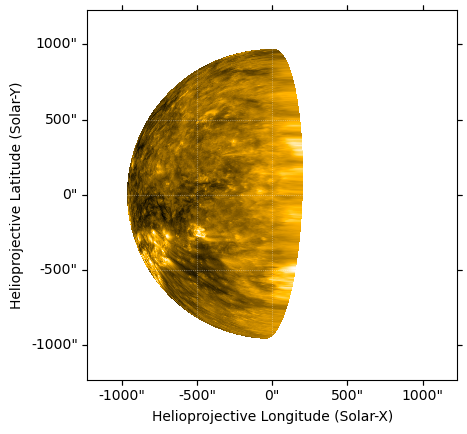

In [31]:
fsi_map_1018_to_aia.plot(title=None, norm=ImageNormalize(
                       vmin=np.nanpercentile(fsi_map_1018_to_aia.data, 0),
                       vmax=np.nanpercentile(fsi_map_1018_to_aia.data, 99.99),
                       stretch=AsinhStretch(0.5)))

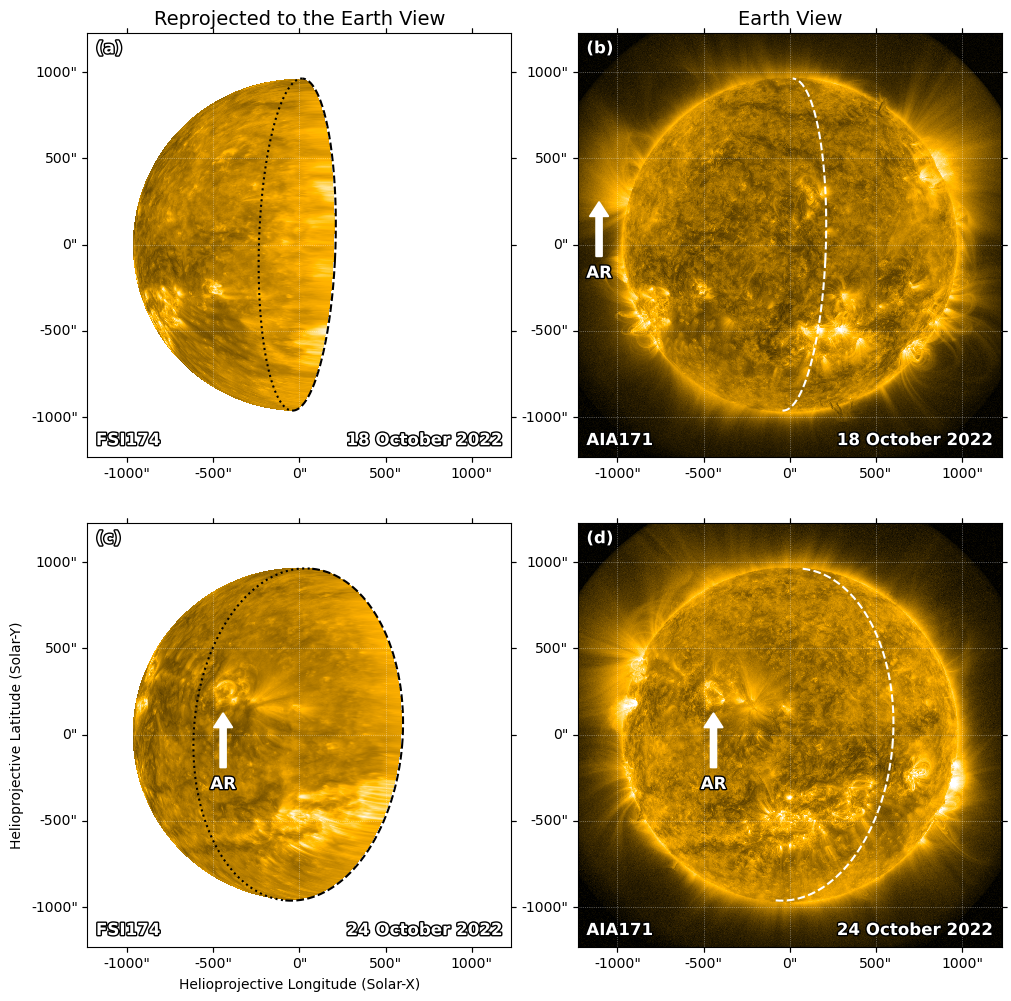

In [34]:
fig = plt.figure(figsize=(10, 10), layout="constrained")

ax1 = fig.add_subplot(2, 2, 1, projection=fsi_map_1018_to_aia)
fsi_map_1018_to_aia.plot(axes=ax1, title=None, norm=ImageNormalize(
                       vmin=np.nanpercentile(fsi_map_1018_crop.data, 0.5),
                       vmax=np.nanpercentile(fsi_map_1018_crop.data, 99.99),
                       stretch=AsinhStretch(0.5)))

ax1.text(0.02, 0.02, "FSI174", color="white", fontsize=12,
        transform=ax1.transAxes, ha="left", va="bottom",
        weight="bold",
        path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                      path_effects.Normal()])

ax1.text(0.98, 0.02, "18 October 2022", color="white", fontsize=12,
         transform=ax1.transAxes, ha="right", va="bottom",
         weight="bold",
         path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                       path_effects.Normal()])

ax1.text(0.02, 0.98, "(a)", color="white", fontsize=12,
         transform=ax1.transAxes, ha="left", va="top",
         weight="bold",
         path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                      path_effects.Normal()])

ax1.set_title("Reprojected to the Earth View", fontsize=14,)

# ax1.annotate("AR", (0.35,0.6), (0.35, 0.45), 
#              fontsize=12,color="white",weight="bold",
#              path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
#                             path_effects.Normal()],
#              va="top", ha="center",
#              bbox=dict(pad=7, facecolor="none", edgecolor="none"),
#              arrowprops=dict(width=4, headwidth=13,
#                             headlength=10,
#                         #  facecolor='#DA291C',
#                             facecolor='white',
#                             linewidth=1.5, edgecolor='#FFFFFF'),
#              xycoords=ax1.transAxes)

ax1_visible_limb, ax1_hidden_limb = fsi_map_1018.draw_limb(axes=ax1, color='black', lw=1.5, alpha=1,)
# ax1_hidden_limb.set_visible(False)
ax1_visible_limb.set_linestyle("--")

ax2 = fig.add_subplot(2, 2, 2, projection=aia_map_1018)
aia_map_1018.plot(axes=ax2, title=None, norm=ImageNormalize(
                       vmin=np.nanpercentile(aia_map_1018.data, 0.5),
                       vmax=np.nanpercentile(aia_map_1018.data, 99.99),
                       stretch=AsinhStretch(0.5)))

ax2.text(0.02, 0.02, "AIA171", color="white", fontsize=12,
        transform=ax2.transAxes, ha="left", va="bottom",
        weight="bold",
        path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                      path_effects.Normal()])

ax2.text(0.98, 0.02, "18 October 2022", color="white", fontsize=12,
        transform=ax2.transAxes, ha="right", va="bottom",
        weight="bold",
        path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                        path_effects.Normal()])

ax2.text(0.02, 0.98, "(b)", color="white", fontsize=12,
            transform=ax2.transAxes, ha="left", va="top",
            weight="bold",
            path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                        path_effects.Normal()])

ax2.set_title("Earth View", fontsize=14,)

ax2.annotate("AR", (0.05,0.6), (0.05, 0.45), 
             fontsize=12,color="white",weight="bold",
             path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                            path_effects.Normal()],
             va="top", ha="center",
             bbox=dict(pad=7, facecolor="none", edgecolor="none"),
             arrowprops=dict(width=4, headwidth=13,
                            headlength=10,
                        #  facecolor='#DA291C',
                            facecolor='white',
                            linewidth=1.5, edgecolor='#FFFFFF'),
             xycoords=ax2.transAxes)

ax2_visible_limb, ax2_hidden_limb = fsi_map_1018.draw_limb(axes=ax2, color='white', lw=1.5, alpha=1, ls="--")
ax2_hidden_limb.set_visible(False)

ax3 = fig.add_subplot(2, 2, 3, projection=fsi_map_1024_to_aia)
fsi_map_1024_to_aia.plot(axes=ax3, title=None, norm=ImageNormalize(
                       vmin=np.nanpercentile(fsi_map_1024_crop.data, 0.5),
                       vmax=np.nanpercentile(fsi_map_1024_crop.data, 99.99),
                       stretch=AsinhStretch(0.5)))

ax3.text(0.02, 0.02, "FSI174", color="white", fontsize=12,
        transform=ax3.transAxes, ha="left", va="bottom",
        weight="bold",
        path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                      path_effects.Normal()])

ax3.text(0.98, 0.02, "24 October 2022", color="white", fontsize=12,
        transform=ax3.transAxes, ha="right", va="bottom",
        weight="bold",
        path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                      path_effects.Normal()])

ax3.text(0.02, 0.98, "(c)", color="white", fontsize=12,
        transform=ax3.transAxes, ha="left", va="top",
        weight="bold",
        path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                      path_effects.Normal()])

ax3.annotate("AR", (0.32,0.55), (0.32, 0.4), 
             fontsize=12,color="white",weight="bold",
             path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                            path_effects.Normal()],
             va="top", ha="center",
             bbox=dict(pad=7, facecolor="none", edgecolor="none"),
             arrowprops=dict(width=4, headwidth=13,
                            headlength=10,
                        #  facecolor='#DA291C',
                            facecolor='white',
                            linewidth=1.5, edgecolor='#FFFFFF'),
             xycoords=ax3.transAxes)

ax3_visible_limb, ax3_hidden_limb = fsi_map_1024.draw_limb(axes=ax3, color='black', lw=1.5, alpha=1)
# ax3_hidden_limb.set_visible(False)
ax3_visible_limb.set_linestyle("--")


ax4 = fig.add_subplot(2, 2, 4, projection=aia_map_1024)
aia_map_1024.plot(axes=ax4, title=None, norm=ImageNormalize(
                       vmin=np.nanpercentile(aia_map_1018.data, 0.5),
                       vmax=np.nanpercentile(aia_map_1018.data, 99.99),
                       stretch=AsinhStretch(0.5)))

ax4.text(0.02, 0.02, "AIA171", color="white", fontsize=12,
        transform=ax4.transAxes, ha="left", va="bottom",
        weight="bold",
        path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                      path_effects.Normal()])

ax4.text(0.98, 0.02, "24 October 2022", color="white", fontsize=12,
        transform=ax4.transAxes, ha="right", va="bottom",
        weight="bold",
        path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                      path_effects.Normal()])

ax4.text(0.02, 0.98, "(d)", color="white", fontsize=12,
        transform=ax4.transAxes, ha="left", va="top",
        weight="bold",
        path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                      path_effects.Normal()])

ax4.annotate("AR", (0.32,0.55), (0.32, 0.4), 
             fontsize=12,color="white",weight="bold",
             path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                            path_effects.Normal()],
             va="top", ha="center",
             bbox=dict(pad=7, facecolor="none", edgecolor="none"),
             arrowprops=dict(width=4, headwidth=13,
                            headlength=10,
                        #  facecolor='#DA291C',
                            facecolor='white',
                            linewidth=1.5, edgecolor='#FFFFFF'),
             xycoords=ax4.transAxes)

ax4_visible_limb, ax4_hidden_limb = fsi_map_1024.draw_limb(axes=ax4, color='white', lw=1.5, alpha=1, ls="--")
ax4_hidden_limb.set_visible(False)

for ax in (ax1,ax2,ax4):
    ax.coords[0].axislabels.set_visible(False)
    ax.coords[1].axislabels.set_visible(False)

fig.savefig("../../figs/KB2025/fig2_backup_repro_drop_offlimb.pdf", dpi=300, bbox_inches="tight")

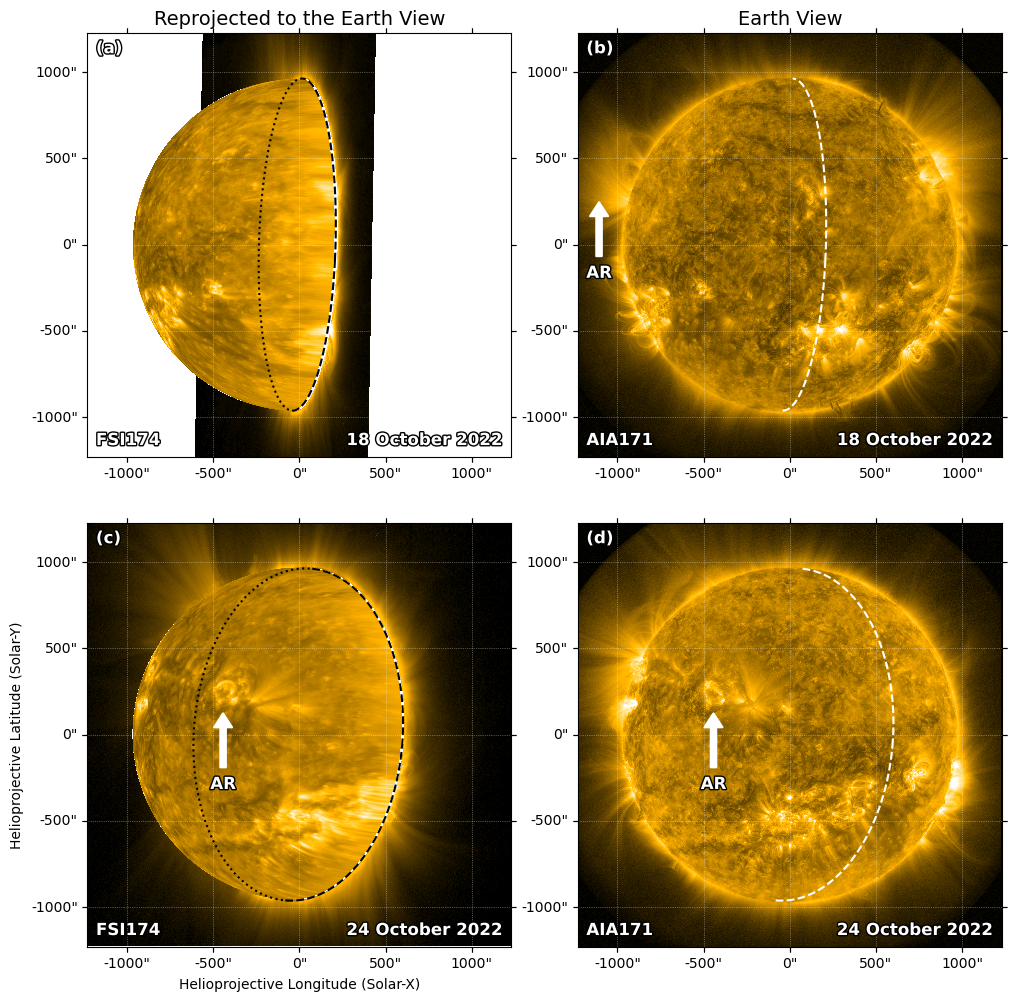

In [35]:
fig = plt.figure(figsize=(10, 10), layout="constrained")

ax1 = fig.add_subplot(2, 2, 1, projection=fsi_map_1018_to_aia_ps)
fsi_map_1018_to_aia_ps.plot(axes=ax1, title=None, norm=ImageNormalize(
                       vmin=np.nanpercentile(fsi_map_1018_crop.data, 0.5),
                       vmax=np.nanpercentile(fsi_map_1018_crop.data, 99.99),
                       stretch=AsinhStretch(0.5)))

ax1.text(0.02, 0.02, "FSI174", color="white", fontsize=12,
        transform=ax1.transAxes, ha="left", va="bottom",
        weight="bold",
        path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                      path_effects.Normal()])

ax1.text(0.98, 0.02, "18 October 2022", color="white", fontsize=12,
         transform=ax1.transAxes, ha="right", va="bottom",
         weight="bold",
         path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                       path_effects.Normal()])

ax1.text(0.02, 0.98, "(a)", color="white", fontsize=12,
         transform=ax1.transAxes, ha="left", va="top",
         weight="bold",
         path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                      path_effects.Normal()])

ax1.set_title("Reprojected to the Earth View", fontsize=14,)

# ax1.annotate("AR", (0.35,0.6), (0.35, 0.45), 
#              fontsize=12,color="white",weight="bold",
#              path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
#                             path_effects.Normal()],
#              va="top", ha="center",
#              bbox=dict(pad=7, facecolor="none", edgecolor="none"),
#              arrowprops=dict(width=4, headwidth=13,
#                             headlength=10,
#                         #  facecolor='#DA291C',
#                             facecolor='white',
#                             linewidth=1.5, edgecolor='#FFFFFF'),
#              xycoords=ax1.transAxes)

ax1_visible_limb, ax1_hidden_limb = fsi_map_1018.draw_limb(axes=ax1, color='black', lw=1.5, alpha=1,)
# ax1_hidden_limb.set_visible(False)
ax1_visible_limb.set_linestyle("--")

ax2 = fig.add_subplot(2, 2, 2, projection=aia_map_1018)
aia_map_1018.plot(axes=ax2, title=None, norm=ImageNormalize(
                       vmin=np.nanpercentile(aia_map_1018.data, 0.5),
                       vmax=np.nanpercentile(aia_map_1018.data, 99.99),
                       stretch=AsinhStretch(0.5)))

ax2.text(0.02, 0.02, "AIA171", color="white", fontsize=12,
        transform=ax2.transAxes, ha="left", va="bottom",
        weight="bold",
        path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                      path_effects.Normal()])

ax2.text(0.98, 0.02, "18 October 2022", color="white", fontsize=12,
        transform=ax2.transAxes, ha="right", va="bottom",
        weight="bold",
        path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                        path_effects.Normal()])

ax2.text(0.02, 0.98, "(b)", color="white", fontsize=12,
            transform=ax2.transAxes, ha="left", va="top",
            weight="bold",
            path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                        path_effects.Normal()])

ax2.set_title("Earth View", fontsize=14,)

ax2.annotate("AR", (0.05,0.6), (0.05, 0.45), 
             fontsize=12,color="white",weight="bold",
             path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                            path_effects.Normal()],
             va="top", ha="center",
             bbox=dict(pad=7, facecolor="none", edgecolor="none"),
             arrowprops=dict(width=4, headwidth=13,
                            headlength=10,
                        #  facecolor='#DA291C',
                            facecolor='white',
                            linewidth=1.5, edgecolor='#FFFFFF'),
             xycoords=ax2.transAxes)

ax2_visible_limb, ax2_hidden_limb = fsi_map_1018.draw_limb(axes=ax2, color='white', lw=1.5, alpha=1, ls="--")
ax2_hidden_limb.set_visible(False)

ax3 = fig.add_subplot(2, 2, 3, projection=fsi_map_1024_to_aia_ps)
fsi_map_1024_to_aia_ps.plot(axes=ax3, title=None, norm=ImageNormalize(
                       vmin=np.nanpercentile(fsi_map_1024_crop.data, 0.5),
                       vmax=np.nanpercentile(fsi_map_1024_crop.data, 99.99),
                       stretch=AsinhStretch(0.5)))

ax3.text(0.02, 0.02, "FSI174", color="white", fontsize=12,
        transform=ax3.transAxes, ha="left", va="bottom",
        weight="bold",
        path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                      path_effects.Normal()])

ax3.text(0.98, 0.02, "24 October 2022", color="white", fontsize=12,
        transform=ax3.transAxes, ha="right", va="bottom",
        weight="bold",
        path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                      path_effects.Normal()])

ax3.text(0.02, 0.98, "(c)", color="white", fontsize=12,
        transform=ax3.transAxes, ha="left", va="top",
        weight="bold",
        path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                      path_effects.Normal()])

ax3.annotate("AR", (0.32,0.55), (0.32, 0.4), 
             fontsize=12,color="white",weight="bold",
             path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                            path_effects.Normal()],
             va="top", ha="center",
             bbox=dict(pad=7, facecolor="none", edgecolor="none"),
             arrowprops=dict(width=4, headwidth=13,
                            headlength=10,
                        #  facecolor='#DA291C',
                            facecolor='white',
                            linewidth=1.5, edgecolor='#FFFFFF'),
             xycoords=ax3.transAxes)

ax3_visible_limb, ax3_hidden_limb = fsi_map_1024.draw_limb(axes=ax3, color='black', lw=1.5, alpha=1)
# ax3_hidden_limb.set_visible(False)
ax3_visible_limb.set_linestyle("--")


ax4 = fig.add_subplot(2, 2, 4, projection=aia_map_1024)
aia_map_1024.plot(axes=ax4, title=None, norm=ImageNormalize(
                       vmin=np.nanpercentile(aia_map_1018.data, 0.5),
                       vmax=np.nanpercentile(aia_map_1018.data, 99.99),
                       stretch=AsinhStretch(0.5)))

ax4.text(0.02, 0.02, "AIA171", color="white", fontsize=12,
        transform=ax4.transAxes, ha="left", va="bottom",
        weight="bold",
        path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                      path_effects.Normal()])

ax4.text(0.98, 0.02, "24 October 2022", color="white", fontsize=12,
        transform=ax4.transAxes, ha="right", va="bottom",
        weight="bold",
        path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                      path_effects.Normal()])

ax4.text(0.02, 0.98, "(d)", color="white", fontsize=12,
        transform=ax4.transAxes, ha="left", va="top",
        weight="bold",
        path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                      path_effects.Normal()])

ax4.annotate("AR", (0.32,0.55), (0.32, 0.4), 
             fontsize=12,color="white",weight="bold",
             path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                            path_effects.Normal()],
             va="top", ha="center",
             bbox=dict(pad=7, facecolor="none", edgecolor="none"),
             arrowprops=dict(width=4, headwidth=13,
                            headlength=10,
                        #  facecolor='#DA291C',
                            facecolor='white',
                            linewidth=1.5, edgecolor='#FFFFFF'),
             xycoords=ax4.transAxes)

ax4_visible_limb, ax4_hidden_limb = fsi_map_1024.draw_limb(axes=ax4, color='white', lw=1.5, alpha=1, ls="--")
ax4_hidden_limb.set_visible(False)

for ax in (ax1,ax2,ax4):
    ax.coords[0].axislabels.set_visible(False)
    ax.coords[1].axislabels.set_visible(False)

fig.savefig("../../figs/KB2025/fig2_backup_repro_planar_offlimb.pdf", dpi=300, bbox_inches="tight")